In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("../data/train.csv")

In [6]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (159571, 8)


In [8]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.2 MB


In [10]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [11]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df[labels].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

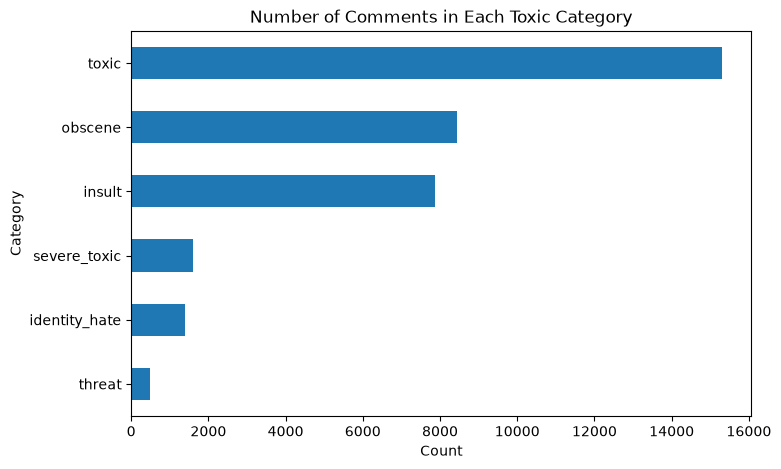

In [13]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df[labels].sum().sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Number of Comments in Each Toxic Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

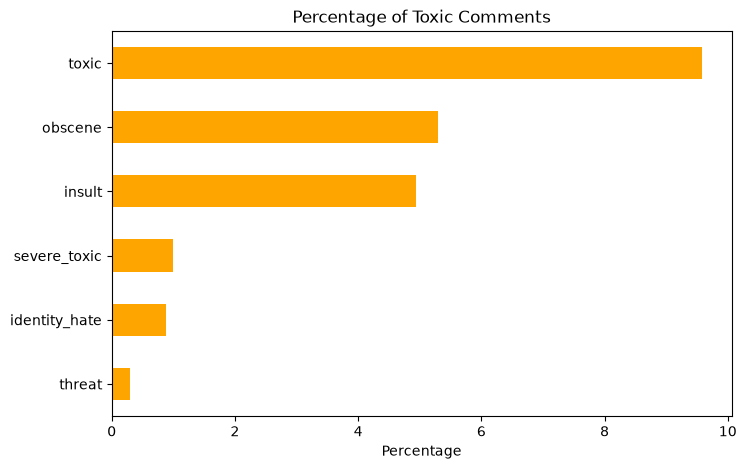

In [14]:
(label_percent := df[labels].mean() * 100).sort_values().plot(
    kind="barh",
    figsize=(8,5),
    color="orange"
)

plt.title("Percentage of Toxic Comments")
plt.xlabel("Percentage")
plt.show()

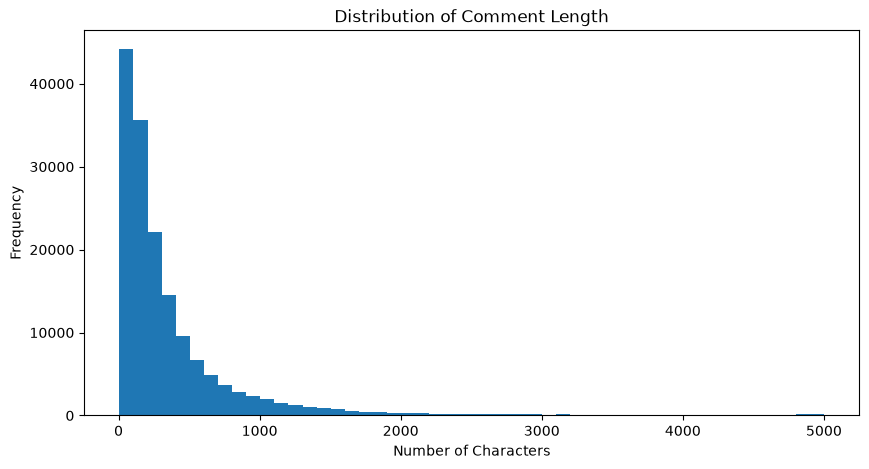

In [15]:
df["comment_length"] = df["comment_text"].apply(len)

plt.figure(figsize=(10,5))
plt.hist(df["comment_length"], bins=50)
plt.title("Distribution of Comment Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [16]:
df["comment_length"].describe()

count    159571.000000
mean        394.073215
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_length, dtype: float64

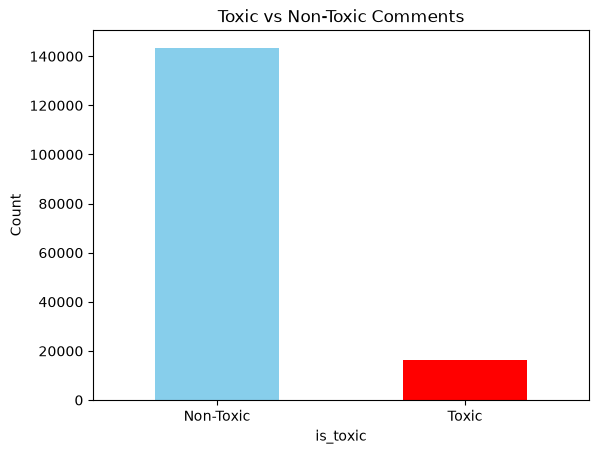

In [17]:
df["is_toxic"] = (df[labels].sum(axis=1) > 0).astype(int)

df["is_toxic"].value_counts().plot(
    kind="bar",
    color=["skyblue", "red"]
)

plt.xticks([0,1], ["Non-Toxic", "Toxic"], rotation=0)
plt.title("Toxic vs Non-Toxic Comments")
plt.ylabel("Count")
plt.show()


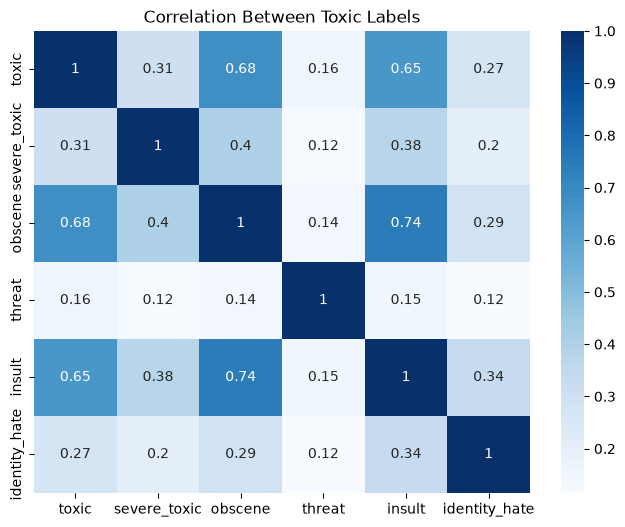

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[labels].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Toxic Labels")
plt.show()

In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import clean_text

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/poojasriab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/poojasriab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/poojasriab/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [20]:
df["clean_comment"] = df["comment_text"].apply(clean_text)

In [21]:
df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,daww match background colour im seemingly stuc...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really trying edit war guy constant...
3,"""\nMore\nI can't make any real suggestions on ...",cant make real suggestion improvement wondered...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page thats


In [22]:
df.to_csv("../data/train_cleaned.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [23]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,is_toxic,clean_comment
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,0,explanation edits made username hardcore metal...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,0,daww match background colour im seemingly stuc...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,0,hey man im really trying edit war guy constant...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,0,cant make real suggestion improvement wondered...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,0,sir hero chance remember page thats


In [24]:
df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,daww match background colour im seemingly stuc...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really trying edit war guy constant...
3,"""\nMore\nI can't make any real suggestions on ...",cant make real suggestion improvement wondered...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page thats


In [25]:
saved_df = pd.read_csv("../data/train_cleaned.csv")

saved_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,is_toxic,clean_comment
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,0,explanation edits made username hardcore metal...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,0,daww match background colour im seemingly stuc...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,0,hey man im really trying edit war guy constant...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,0,cant make real suggestion improvement wondered...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,0,sir hero chance remember page thats


In [26]:


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [27]:
vocab_size = 20000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_comment"])

In [28]:
sequences = tokenizer.texts_to_sequences(df["clean_comment"])

In [29]:
print(df["clean_comment"][0])
print(sequences[0])

explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since im retired
[463, 55, 58, 533, 4155, 10206, 647, 227, 1848, 128, 5465, 2197, 2520, 49, 987, 10207, 2545, 7, 10, 147, 222, 5, 3, 70, 16, 3070]


In [30]:
max_length = 200

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [31]:
print(X.shape)

(159571, 200)


In [32]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

y = df[labels]

In [33]:
print(y.shape)

(159571, 6)


In [34]:
import pickle

with open("../models/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [42]:
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=40000,
    random_state=42
)

In [43]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (127656, 200)
X_test : (31915, 200)
y_train: (127656, 6)
y_test : (31915, 6)


In [44]:
print(X_train.dtype)
print(y_train.dtypes)

int32
toxic            int64
severe_toxic     int64
obscene          int64
threat           int64
insult           int64
identity_hate    int64
dtype: object


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SpatialDropout1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

In [46]:
vocab_size = 20000
embedding_dim = 64
max_length = 200

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    ),

    SpatialDropout1D(0.2),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(6, activation="sigmoid")
])

In [47]:
model.build(input_shape=(None, max_length))

In [48]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,350,374 (5.15 MB)

 Trainable params: 1,350,374 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "../models/best_toxic_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [65]:
history = model.fit(
    X_small,
    y_small,
    epochs=2,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 188ms/step - accuracy: 0.9847 - loss: 0.0404 - val_accuracy: 0.9942 - val_loss: 0.0478
Epoch 2/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 178ms/step - accuracy: 0.9554 - loss: 0.0371 - val_accuracy: 0.9942 - val_loss: 0.0507


In [66]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

998/998 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9941 - loss: 0.0587
Test Loss: 0.05868760123848915
Test Accuracy: 0.9941093325614929


In [67]:
model.save("../models/toxic_comment_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [68]:
import numpy as np

labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

test_comments = [
    "You are wonderful.",
    "I hate you. You are an idiot.",
    "Go kill yourself.",
    "Have a nice day.",
    "You stupid fool."
]

seq = tokenizer.texts_to_sequences(test_comments)
pad = pad_sequences(seq, maxlen=200, padding="post", truncating="post")

predictions = model.predict(pad)

for comment, pred in zip(test_comments, predictions):
    print("\nComment:", comment)
    print("-" * 50)

    for label, prob in zip(labels, pred):
        print(f"{label:15}: {prob:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

Comment: You are wonderful.
--------------------------------------------------
toxic          : 0.004
severe_toxic   : 0.000
obscene        : 0.000
threat         : 0.000
insult         : 0.000
identity_hate  : 0.000

Comment: I hate you. You are an idiot.
--------------------------------------------------
toxic          : 0.962
severe_toxic   : 0.032
obscene        : 0.696
threat         : 0.034
insult         : 0.565
identity_hate  : 0.081

Comment: Go kill yourself.
--------------------------------------------------
toxic          : 0.955
severe_toxic   : 0.019
obscene        : 0.645
threat         : 0.024
insult         : 0.500
identity_hate  : 0.065

Comment: Have a nice day.
--------------------------------------------------
toxic          : 0.017
severe_toxic   : 0.000
obscene        : 0.002
threat         : 0.000
insult         : 0.001
identity_hate  : 0.000

Comment: You stupid fool.
--------------------------------------------------
tox

In [69]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.3).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=labels,
    zero_division=0
))

998/998 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step
               precision    recall  f1-score   support

        toxic       0.75      0.79      0.77      3056
 severe_toxic       0.47      0.51      0.49       321
      obscene       0.76      0.81      0.78      1715
       threat       0.00      0.00      0.00        74
       insult       0.66      0.76      0.71      1614
identity_hate       0.18      0.01      0.01       294

    micro avg       0.71      0.73      0.72      7074
    macro avg       0.47      0.48      0.46      7074
 weighted avg       0.69      0.73      0.70      7074
  samples avg       0.07      0.07      0.06      7074



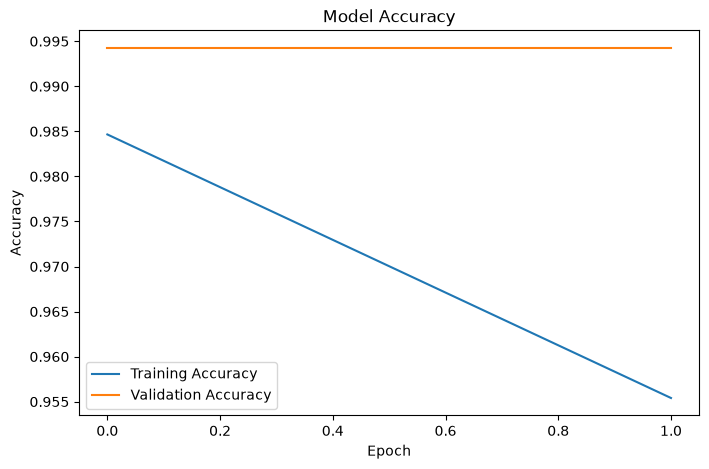

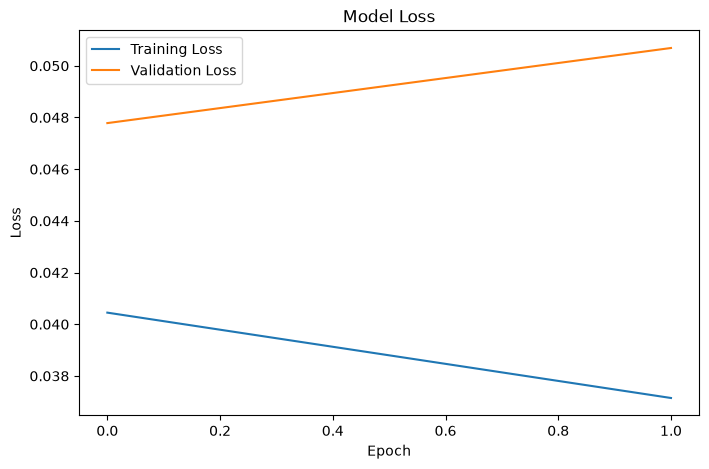

In [70]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()